In [1]:
import os

In [2]:
%pwd

'c:\\Users\\LENOVO\\Fraud-Transaction-Detection\\notebooks'

In [3]:
os.chdir("../")

In [4]:
%pwd

'c:\\Users\\LENOVO\\Fraud-Transaction-Detection'

In [6]:
import os
import pandas as pd

# Path to data folder
data_folder = 'data/'

# List all .pkl files
pkl_files = [file for file in os.listdir(data_folder) if file.endswith('.pkl')]

# Load and concatenate all pkl files
dataframes = []
for file in pkl_files:
    file_path = os.path.join(data_folder, file)
    df = pd.read_pickle(file_path)
    dataframes.append(df)

# Combine all dataframes into one
df_full = pd.concat(dataframes, ignore_index=True)

# Show basic info
print("Shape of combined dataset:", df_full.shape)
df_full.head()


Shape of combined dataset: (1754155, 9)


,TRANSACTION_ID,TX_DATETIME,CUSTOMER_ID,TERMINAL_ID,TX_AMOUNT,TX_TIME_SECONDS,TX_TIME_DAYS,TX_FRAUD,TX_FRAUD_SCENARIO
0,0,2018-04-01 00:00:31,596,3156,57.16,31,0,0,0
1,1,2018-04-01 00:02:10,4961,3412,81.51,130,0,0,0
2,2,2018-04-01 00:07:56,2,1365,146.00,476,0,0,0
3,3,2018-04-01 00:09:29,4128,8737,64.49,569,0,0,0
4,4,2018-04-01 00:10:34,927,9906,50.99,634,0,0,0


In [7]:
# Display basic info
df_full.info()

# Check for missing values
print("\nMissing values:\n", df_full.isnull().sum())

# Show summary statistics for numeric columns
df_full.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1754155 entries, 0 to 1754154
Data columns (total 9 columns):
 #   Column             Dtype         
---  ------             -----         
 0   TRANSACTION_ID     int64         
 1   TX_DATETIME        datetime64[ns]
 2   CUSTOMER_ID        object        
 3   TERMINAL_ID        object        
 4   TX_AMOUNT          float64       
 5   TX_TIME_SECONDS    object        
 6   TX_TIME_DAYS       object        
 7   TX_FRAUD           int64         
 8   TX_FRAUD_SCENARIO  int64         
dtypes: datetime64[ns](1), float64(1), int64(3), object(4)
memory usage: 120.4+ MB

Missing values:
 TRANSACTION_ID       0
TX_DATETIME          0
CUSTOMER_ID          0
TERMINAL_ID          0
TX_AMOUNT            0
TX_TIME_SECONDS      0
TX_TIME_DAYS         0
TX_FRAUD             0
TX_FRAUD_SCENARIO    0
dtype: int64


,TRANSACTION_ID,TX_DATETIME,TX_AMOUNT,TX_FRAUD,TX_FRAUD_SCENARIO
count,1.754155e+06,1754155,1.754155e+06,1.754155e+06,1.754155e+06
mean,8.770770e+05,2018-07-01 11:20:33.708572160,5.363230e+01,8.369272e-03,1.882388e-02
min,0.000000e+00,2018-04-01 00:00:31,0.000000e+00,0.000000e+00,0.000000e+00
25%,4.385385e+05,2018-05-16 14:40:46.500000,2.101000e+01,0.000000e+00,0.000000e+00
50%,8.770770e+05,2018-07-01 11:11:10,4.464000e+01,0.000000e+00,0.000000e+00
75%,1.315616e+06,2018-08-16 08:01:01.500000,7.695000e+01,0.000000e+00,0.000000e+00
max,1.754154e+06,2018-09-30 23:59:57,2.628000e+03,1.000000e+00,3.000000e+00
std,5.063811e+05,NaN,4.232649e+01,9.110012e-02,2.113263e-01


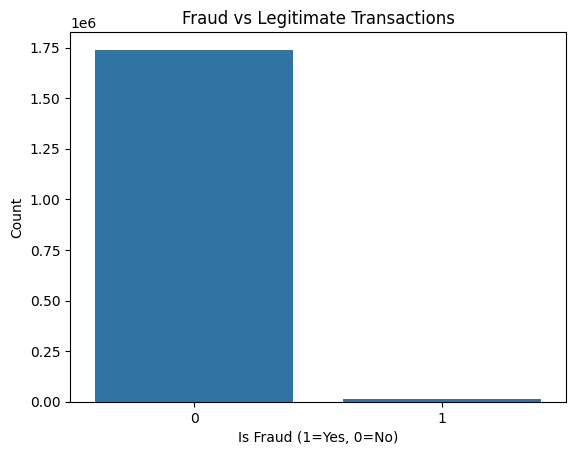

TX_FRAUD
0    1739474
1      14681
Name: count, dtype: int64


In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

# Count plot of TX_FRAUD
sns.countplot(x='TX_FRAUD', data=df_full)
plt.title("Fraud vs Legitimate Transactions")
plt.xlabel("Is Fraud (1=Yes, 0=No)")
plt.ylabel("Count")
plt.show()

# Print actual numbers
print(df_full['TX_FRAUD'].value_counts())


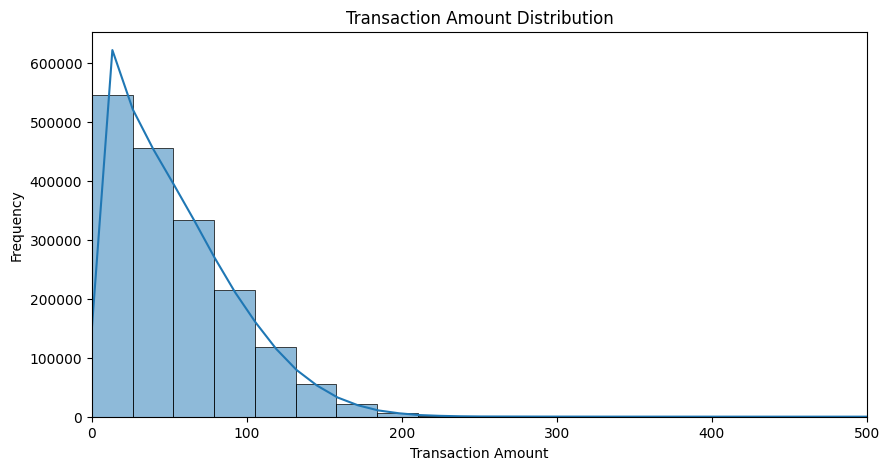

In [9]:
plt.figure(figsize=(10, 5))
sns.histplot(df_full['TX_AMOUNT'], bins=100, kde=True)
plt.title("Transaction Amount Distribution")
plt.xlabel("Transaction Amount")
plt.ylabel("Frequency")
plt.xlim(0, 500)  # zoom in for readability
plt.show()


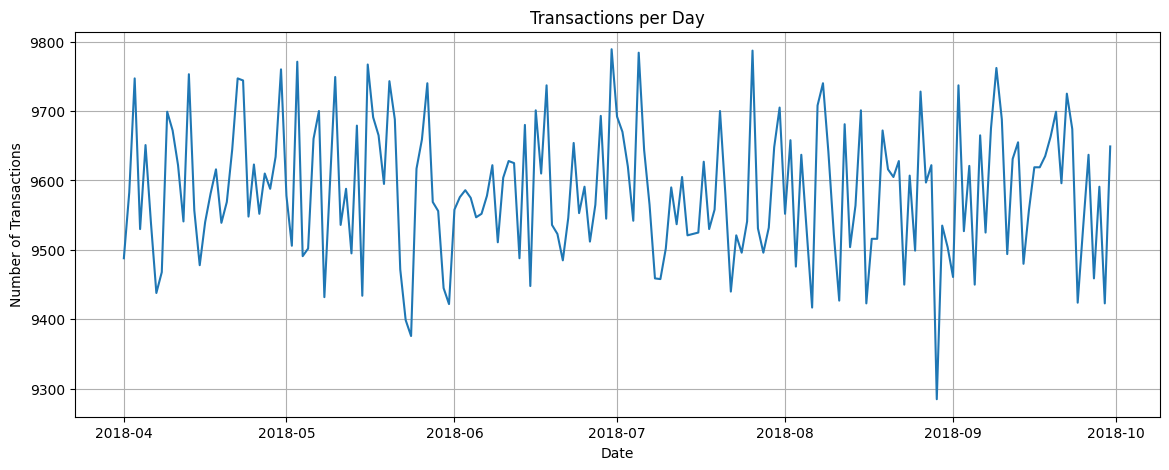

In [10]:
# Convert TX_DATETIME to datetime type
df_full['TX_DATETIME'] = pd.to_datetime(df_full['TX_DATETIME'])

# Plot transactions per day
df_full['TX_DATE'] = df_full['TX_DATETIME'].dt.date
tx_per_day = df_full.groupby('TX_DATE').size()

tx_per_day.plot(figsize=(14, 5))
plt.title("Transactions per Day")
plt.xlabel("Date")
plt.ylabel("Number of Transactions")
plt.grid()
plt.show()


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_34776\3201037400.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_fraud_terminals.values, y=top_fraud_terminals.index, palette="Reds_r")


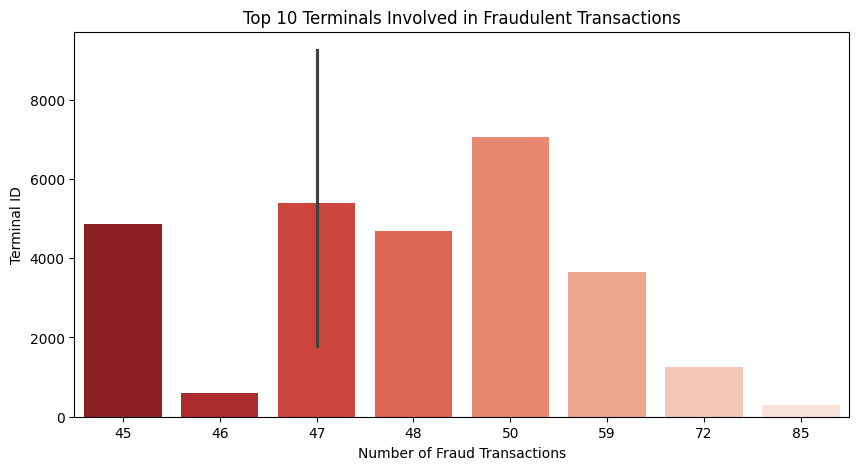

In [11]:
# Terminals with the highest number of frauds
top_fraud_terminals = df_full[df_full['TX_FRAUD'] == 1]['TERMINAL_ID'].value_counts().head(10)

plt.figure(figsize=(10, 5))
sns.barplot(x=top_fraud_terminals.values, y=top_fraud_terminals.index, palette="Reds_r")
plt.title("Top 10 Terminals Involved in Fraudulent Transactions")
plt.xlabel("Number of Fraud Transactions")
plt.ylabel("Terminal ID")
plt.show()


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_34776\250766096.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_fraud_customers.values, y=top_fraud_customers.index, palette="Purples_r")


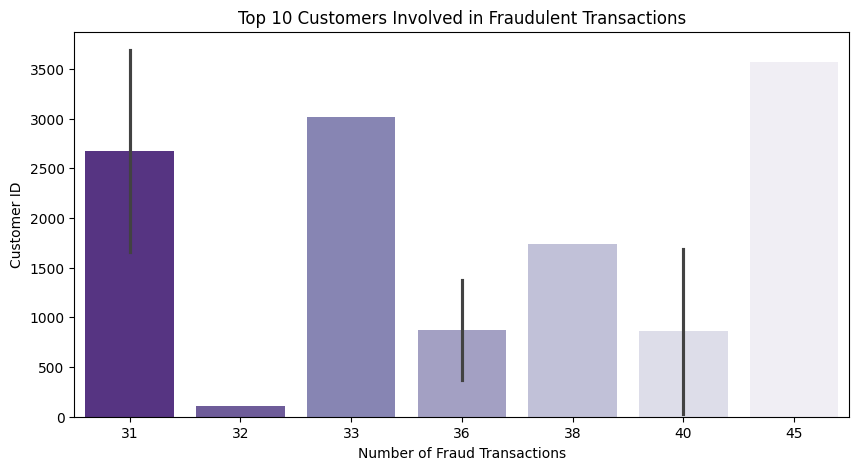

In [12]:
# Customers with the highest number of frauds
top_fraud_customers = df_full[df_full['TX_FRAUD'] == 1]['CUSTOMER_ID'].value_counts().head(10)

plt.figure(figsize=(10, 5))
sns.barplot(x=top_fraud_customers.values, y=top_fraud_customers.index, palette="Purples_r")
plt.title("Top 10 Customers Involved in Fraudulent Transactions")
plt.xlabel("Number of Fraud Transactions")
plt.ylabel("Customer ID")
plt.show()


In [15]:
# Extract hour, day, weekday
df_full['TX_HOUR'] = df_full['TX_DATETIME'].dt.hour
df_full['TX_DAY'] = df_full['TX_DATETIME'].dt.day
df_full['TX_WEEKDAY'] = df_full['TX_DATETIME'].dt.weekday


In [17]:
def compute_terminal_fraud_rolling(df, window='7d'):
    df = df.sort_values('TX_DATETIME')
    results = []

    for terminal_id, group in df.groupby('TERMINAL_ID'):
        group = group.set_index('TX_DATETIME')
        group = group.sort_index()
        group['TERMINAL_FRAUD_7D'] = group['TX_FRAUD'].rolling(window=window).sum().shift(1).fillna(0)
        results.append(group.reset_index())

    return pd.concat(results, ignore_index=True)

df_full = compute_terminal_fraud_rolling(df_full)


In [18]:
def compute_customer_spend_rolling(df, window='7d'):
    df = df.sort_values('TX_DATETIME')
    results = []

    for customer_id, group in df.groupby('CUSTOMER_ID'):
        group = group.set_index('TX_DATETIME')
        group = group.sort_index()
        group['CUSTOMER_SPEND_7D'] = group['TX_AMOUNT'].rolling(window=window).mean().shift(1).fillna(0)
        results.append(group.reset_index())

    return pd.concat(results, ignore_index=True)

df_full = compute_customer_spend_rolling(df_full)


In [19]:
# Define feature columns
feature_cols = [
    'TX_AMOUNT',
    'TX_HOUR',
    'TX_DAY',
    'TX_WEEKDAY',
    'TERMINAL_FRAUD_7D',
    'CUSTOMER_SPEND_7D'
]

# Define target column
target_col = 'TX_FRAUD'

# Extract final feature and label data
X = df_full[feature_cols]
y = df_full[target_col]


In [20]:
from sklearn.model_selection import train_test_split

# Split the full dataframe by TX_DATETIME
df_full = df_full.sort_values('TX_DATETIME')
split_index = int(0.8 * len(df_full))

X_train = X.iloc[:split_index]
y_train = y.iloc[:split_index]

X_test = X.iloc[split_index:]
y_test = y.iloc[split_index:]


In [21]:
# 📦 Step 1: Import libraries
import pickle
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import joblib
import os


In [23]:
# 📥 Step 2: Load processed data

with open('processed/X_train.pkl', 'rb') as f:
    X_train = pickle.load(f)

with open('processed/y_train.pkl', 'rb') as f:
    y_train = pickle.load(f)

with open('processed/X_test.pkl', 'rb') as f:
    X_test = pickle.load(f)

with open('processed/y_test.pkl', 'rb') as f:
    y_test = pickle.load(f)

print("✅ Data loaded.")


✅ Data loaded.


In [24]:
# 🤖 Step 3: Train Random Forest Classifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight='balanced',  # handle imbalance
    n_jobs=-1
)

rf_model.fit(X_train, y_train)
print("✅ Model trained.")


✅ Model trained.


In [25]:
# 📊 Step 4: Evaluate the model

y_pred = rf_model.predict(X_test)
y_proba = rf_model.predict_proba(X_test)[:, 1]

print("✅ Classification Report:\n", classification_report(y_test, y_pred))
print("🔢 Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("📈 ROC AUC Score: {:.4f}".format(roc_auc_score(y_test, y_proba)))


✅ Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00    347681
           1       0.88      0.77      0.82      3150

    accuracy                           1.00    350831
   macro avg       0.94      0.89      0.91    350831
weighted avg       1.00      1.00      1.00    350831

🔢 Confusion Matrix:
 [[347342    339]
 [   710   2440]]
📈 ROC AUC Score: 0.9476
